# 2.5 — Matrix multiplication, at the computer

Worksheet first — the hand reps matter most this week. Here you'll check them,
read a real shape-mismatch error calmly, and *see* why order matters.

In [1]:
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt

In [2]:
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])

print("A @ B =\n", A @ B)                 # the real product — check your worksheet B5a
print("\nnp.matmul(A, B) =\n", np.matmul(A, B), "   <- same thing, spelled out")
print("\nA * B =\n", A * B, "   <- element-wise: the worksheet C9 trap, live")
print("\nB @ A =\n", B @ A, "   <- different from A @ B. Order matters!")

A @ B =
 [[19 22]
 [43 50]]

np.matmul(A, B) =
 [[19 22]
 [43 50]]    <- same thing, spelled out

A * B =
 [[ 5 12]
 [21 32]]    <- element-wise: the worksheet C9 trap, live

B @ A =
 [[23 34]
 [31 46]]    <- different from A @ B. Order matters!


## 1. The shape rule, enforced by numpy

$(m\times n)(n\times p) = (m\times p)$ — inner numbers must match. When they don't, numpy
refuses, and its error message tells you exactly which numbers collided. Learning to *read*
that message is a genuine ML skill — half of real deep-learning debugging is shape errors.

In [3]:
P = np.ones((2, 3))     # np.ones(shape) -> a matrix of 1s, handy for shape experiments
Q = np.ones((3, 5))

print("P.shape =", P.shape, ", Q.shape =", Q.shape)
print("(P @ Q).shape =", (P @ Q).shape, "   <- (2x3)(3x5) = (2x5): inner 3s cancel")

# Now the illegal one — try/except lets us catch the error and read it instead of crashing:
try:
    Q @ P                                  # (3x5)(2x3): inner 5 and 2 collide
except ValueError as e:
    print("\nnumpy says no:", e)
# Read the message: 'mismatch ... (dim 1) != (dim 0)' — it's naming the inner numbers.

# YOUR TURN — worksheet Part A: predict, then test all four with np.ones. A3 should error.

P.shape = (2, 3) , Q.shape = (3, 5)
(P @ Q).shape = (2, 5)    <- (2x3)(3x5) = (2x5): inner 3s cancel

numpy says no: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 5)


## 2. Why the rule: composition, visible

$SR$ means "rotate ($R$) first, then stretch ($S$)" — the vector enters from the right.
Worksheet D12, now on a whole shape. Predict which picture is which before running.

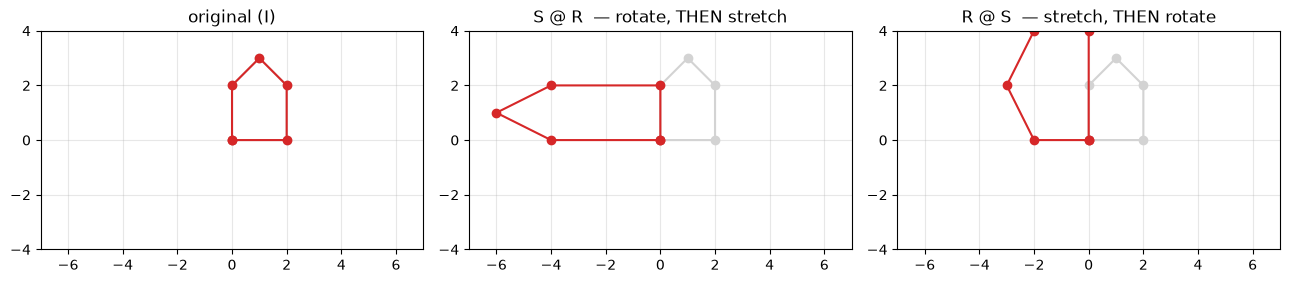

In [4]:
house = np.array([[0, 2, 2, 1, 0, 0],
                  [0, 0, 2, 3, 2, 0]])

R = np.array([[0, -1], [1, 0]])   # rotate 90 deg anticlockwise
S = np.array([[2, 0],  [0, 1]])   # stretch x by 2

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (title, M) in zip(axes, [("original (I)", np.eye(2)),
                                 ("S @ R  — rotate, THEN stretch", S @ R),
                                 ("R @ S  — stretch, THEN rotate", R @ S)]):
    new = M @ house
    ax.plot(house[0], house[1], "o-", color="lightgrey")
    ax.plot(new[0], new[1], "o-", color="C3")
    ax.set_title(title)
    ax.grid(alpha=0.3); ax.set_aspect("equal")
    ax.set_xlim(-7, 7); ax.set_ylim(-4, 4)
plt.tight_layout(); plt.show()
# Same two machines, different order, visibly different results: AB != BA.

In [5]:
# The lesson's deep-end question, tested: collapse a 3-layer pipeline into ONE matrix.
rng = np.random.default_rng(42)
A1 = rng.standard_normal((100, 2))     # layer 1: takes 2 numbers in, puts 100 out
A2 = rng.standard_normal((50, 100))    # layer 2: 100 in, 50 out
A3 = rng.standard_normal((1, 50))      # layer 3: 50 in, 1 out

v = np.array([0.5, -1.0])

step_by_step = A3 @ (A2 @ (A1 @ v))    # three multiplications per input
M = A3 @ A2 @ A1                       # pre-combine the machines ONCE...
collapsed = M @ v                      # ...then one multiplication per input

print("step-by-step:", step_by_step)
print("collapsed:   ", collapsed)
print("identical?   ", np.allclose(step_by_step, collapsed))   # allclose = 'equal, allowing tiny rounding'
print("M.shape =", M.shape, " <- (1x50)(50x100)(100x2) collapsed to (1x2)")

step-by-step: [-27.54669631]
collapsed:    [-27.54669631]
identical?    True
M.shape = (1, 2)  <- (1x50)(50x100)(100x2) collapsed to (1x2)


In [6]:
# YOUR TURN
# 1) Verify worksheet B5b and B6 with @ (both orders).

# 2) Worksheet D13: compute R @ R and apply it to the house. What single machine is R squared?
#    Then try R @ R @ R @ R — what comes back?

# 3) Worksheet C10, live: W = np.ones((64, 128)); X = np.ones((32, 128)).
#    Confirm W @ X errors, then make X @ W.T run and print its shape.
#    (.T is the transpose — flips a matrix over its diagonal.)

## 3. 🌀 One honest number

GPT-class models are, computationally, mostly this one operation. Each layer: a matmul.
Attention scores: matmuls of queries against keys. Generating a single word of a chatbot's
reply takes on the order of a **trillion** multiply-and-adds — every one of them the same
row·column move you just did by hand with your finger sliding across the page.

You didn't learn a toy version today. You learned the actual thing.

---
*Photograph your worksheet into `scans/inbox/`. Next: 2.6 — images are matrices,
and you get to paint with everything you've built.*